# IMDB Sentiment Classification: Embedding + LSTM

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results_dir = project_root / "results"
models_dir = project_root / "models"
results_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)

VOCAB_SIZE = 10000
MAX_LEN = 200

print("Imports ready")
print("Project root:", project_root)
print("VOCAB_SIZE:", VOCAB_SIZE, "MAX_LEN:", MAX_LEN)

Imports ready
Project root: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 5/nlp-imdb-lstm
VOCAB_SIZE: 10000 MAX_LEN: 200


## Section 1: Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("len(X_train):", len(X_train))
print("len(X_test):", len(X_test))

len(X_train): 25000
len(X_test): 25000


## Section 2: Text Preprocessing (Padding)

In [3]:
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)

X_train.shape: (25000, 200)
X_test.shape: (25000, 200)


## Section 3: Build Embedding + LSTM Model

In [4]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(MAX_LEN,)),
        keras.layers.Embedding(VOCAB_SIZE, 128),
        keras.layers.Bidirectional(
            keras.layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2)
        ),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,551,425 (5.92 MB)

 Trainable params: 1,551,425 (5.92 MB)

 Non-trainable params: 0 (0.00 B)

## Section 4: Train the Model

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1,
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Epoch 1/10



  1/625 ━━━━━━━━━━━━━━━━━━━━ 21:13 2s/step - accuracy: 0.6562 - loss: 0.6901


  2/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.6094 - loss: 0.6908


  3/625 ━━━━━━━━━━━━━━━━━━━━ 38s 62ms/step - accuracy: 0.5625 - loss: 0.6926


  4/625 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.5781 - loss: 0.6904

...


622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9717 - loss: 0.0934


623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9717 - loss: 0.0934


624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9717 - loss: 0.0934


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9716 - loss: 0.0936


625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9716 - loss: 0.0936 - val_accuracy: 0.8468 - val_loss: 0.5230 - learning_rate: 2.5000e-04


## Section 5: Evaluate with Precision, Recall, F1-score

In [6]:
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Negative", "Positive"]
    )
)

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"],
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).transpose()
report_csv = results_dir / "classification_report.csv"
report_df.to_csv(report_csv)
print("Saved:", report_csv)

overall_test_acc = float((y_pred == y_test).mean())
print(f"Overall Test Accuracy: {overall_test_acc * 100:.2f}%")

Confusion matrix:
[[10989  1511]
 [ 2906  9594]]

Classification report:
              precision    recall  f1-score   support

    Negative       0.79      0.88      0.83     12500
    Positive       0.86      0.77      0.81     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 5/nlp-imdb-lstm/results/classification_report.csv
Overall Test Accuracy: 82.33%


## Section 6: Visualize Results

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 5/nlp-imdb-lstm/results/training_curves.png


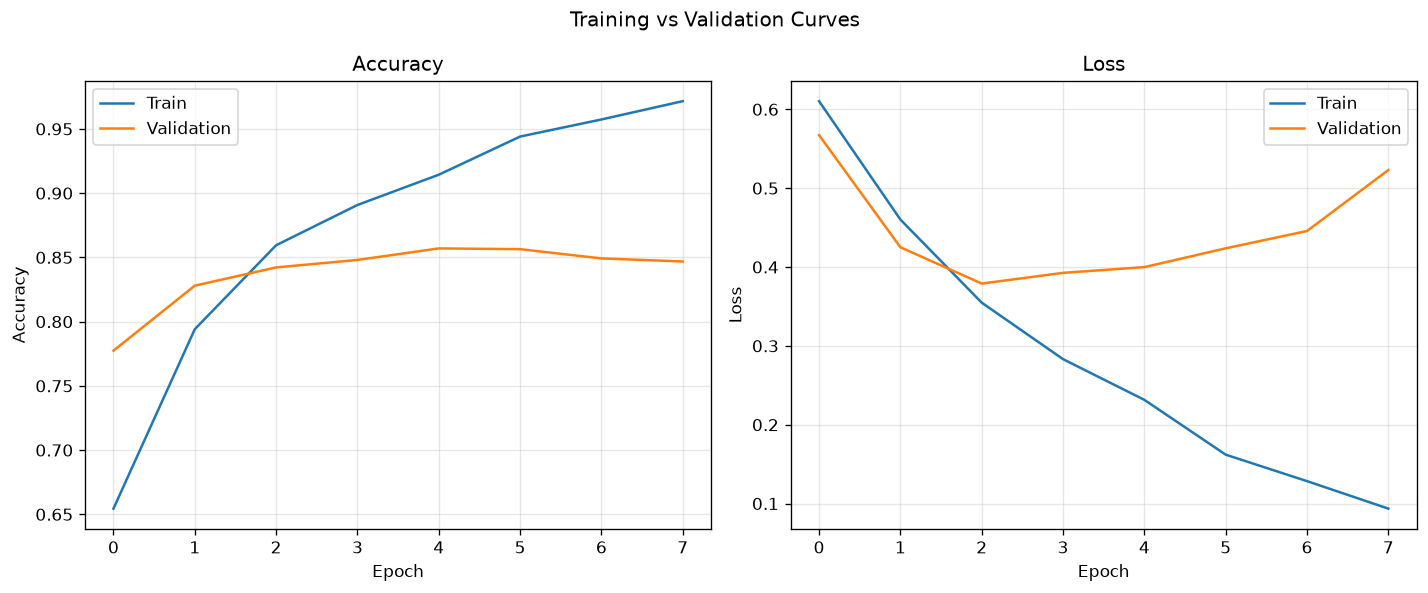

Saved: /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 5/nlp-imdb-lstm/results/confusion_matrix.png


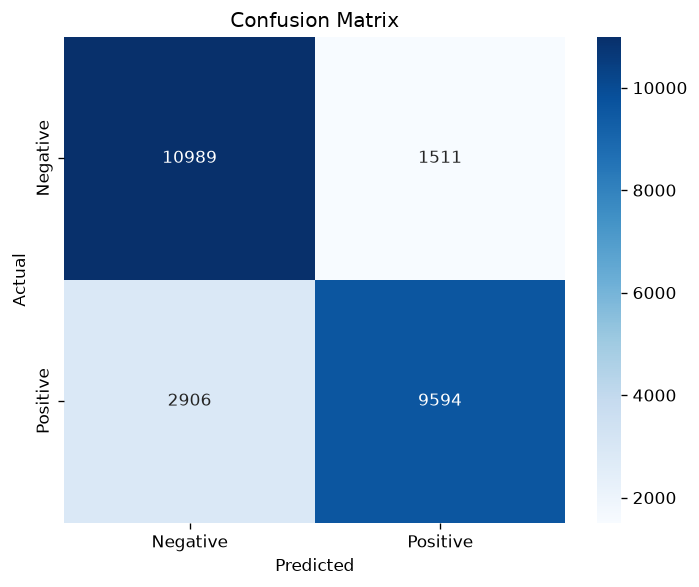

In [7]:
from IPython.display import Image, display

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Training vs Validation Curves")
fig.tight_layout()
curves_path = results_dir / "training_curves.png"
fig.savefig(curves_path, dpi=120, bbox_inches="tight")
plt.close(fig)
print("Saved:", curves_path)
display(Image(filename=str(curves_path)))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
fig.tight_layout()
cm_path = results_dir / "confusion_matrix.png"
fig.savefig(cm_path, dpi=120, bbox_inches="tight")
plt.close(fig)
print("Saved:", cm_path)
display(Image(filename=str(cm_path)))

## Section 7: Save Model

In [8]:
model_path = models_dir / "imdb_lstm.keras"
model.save(model_path)

print(f"Saved model to {model_path} (Keras .keras format)")
print("Text Preprocessed and Padded")
print("Embedding + LSTM Model Trained")
print(f"Overall Test Accuracy: {overall_test_acc * 100:.2f}%")
print("Evaluation Metrics Generated")

Saved model to /Users/yuvrajgole/Documents/DL Experiments/DL Experiment 5/nlp-imdb-lstm/models/imdb_lstm.keras (Keras .keras format)
Text Preprocessed and Padded
Embedding + LSTM Model Trained
Overall Test Accuracy: 82.33%
Evaluation Metrics Generated


## Section 8: Results Summary

In [9]:
summary_table = pd.DataFrame(
    {
        "Class": ["Negative", "Positive"],
        "Precision": [
            report_dict["Negative"]["precision"],
            report_dict["Positive"]["precision"],
        ],
        "Recall": [
            report_dict["Negative"]["recall"],
            report_dict["Positive"]["recall"],
        ],
        "F1-Score": [
            report_dict["Negative"]["f1-score"],
            report_dict["Positive"]["f1-score"],
        ],
    }
)
print(summary_table.to_string(index=False))
summary_table

   Class  Precision  Recall  F1-Score
Negative   0.790860 0.87912  0.832658
Positive   0.863935 0.76752  0.812879


,Class,Precision,Recall,F1-Score
0,Negative,0.790860,0.87912,0.832658
1,Positive,0.863935,0.76752,0.812879


### Completion Checklist

- [x] Text Preprocessed and Padded
- [x] Embedding + LSTM Model Trained
- [x] Overall Test Accuracy: 82.33%
- [x] Evaluation Metrics Generated